# Data Science Project 

## Research Question : Does a higher share of electric vehicles in the national car fleet reduce NOx emissions in EU countries ?

### By Alina Loacker, Amanda Loeb and Max Laurent

#### Under the supervision of Dr. Edoardo Chiarotti and Dr. Quentin Gallea

# Data cleaning and univariate analysis for evolution of electric cars

### Import Packages

In [479]:
import pandas as pd
import numpy as np
import plotly.express as px
import statsmodels
import plotly.io as pio
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.colors import sample_colorscale
import seaborn as sns
pio.renderers.default = "notebook"
import os
os.getcwd()

'/Users/maxlaurent/Documents/GitHub/Data_Science_Project'

### Load Data
You need to download the following file: https://www.dropbox.com/scl/fi/q3ei8expvumspa6gaii17/cars_total-ev.csv?rlkey=281ft04hxha9fi2jp7hfr3jjo&st=4efbs54j&dl=0

In [480]:
df_cars_complete = pd.read_csv("cars_total-ev.csv")

df_cars_complete.head()

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,unit,Unit of measure,mot_nrg,Motor energy,geo,...,TIME_PERIOD,Time,leg_form,Legal form,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
0,dataflow,ESTAT:ROAD_EQS_CARPDA(1.0),Passenger cars by type of motor energy,A,Annual,NR,Number,ELC,Electricity,AL,...,2016,NaN,TOTAL,Total,13,NaN,NaN,NaN,NaN,NaN
1,dataflow,ESTAT:ROAD_EQS_CARPDA(1.0),Passenger cars by type of motor energy,A,Annual,NR,Number,ELC,Electricity,AL,...,2017,NaN,TOTAL,Total,48,NaN,NaN,NaN,NaN,NaN
2,dataflow,ESTAT:ROAD_EQS_CARPDA(1.0),Passenger cars by type of motor energy,A,Annual,NR,Number,ELC,Electricity,AL,...,2018,NaN,TOTAL,Total,102,NaN,NaN,NaN,NaN,NaN
3,dataflow,ESTAT:ROAD_EQS_CARPDA(1.0),Passenger cars by type of motor energy,A,Annual,NR,Number,ELC,Electricity,AL,...,2019,NaN,TOTAL,Total,124,NaN,NaN,NaN,NaN,NaN
4,dataflow,ESTAT:ROAD_EQS_CARPDA(1.0),Passenger cars by type of motor energy,A,Annual,NR,Number,ELC,Electricity,AL,...,2020,NaN,TOTAL,Total,362,NaN,NaN,NaN,NaN,NaN


### Restructure dataset

In [481]:
df_cars_complete.columns

Index(['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'freq', 'Time frequency',
       'unit', 'Unit of measure', 'mot_nrg', 'Motor energy', 'geo',
       'Geopolitical entity (reporting)', 'TIME_PERIOD', 'Time', 'leg_form',
       'Legal form', 'OBS_VALUE', 'Observation value', 'OBS_FLAG',
       'Observation status (Flag) V2 structure', 'CONF_STATUS',
       'Confidentiality status (flag)'],
      dtype='str')

In [482]:
df_cars= (
    df_cars_complete[
        ["Geopolitical entity (reporting)",
            "TIME_PERIOD",
            "Motor energy",
            "OBS_VALUE" ]]
    .rename(columns={
        "Geopolitical entity (reporting)": "Country",
        "TIME_PERIOD": "Year",
        "Motor energy": "",
        "OBS_VALUE": "Cars"
    })
    .query("Year <= 2024")
    .pivot_table(
        index=["Country", "Year"],
        columns="",
        values="Cars"
    )
    .reset_index()
)

df_cars.head()

,Country,Year,Electricity,Total
0,Albania,2016,13.0,435613.0
1,Albania,2017,48.0,417426.0
2,Albania,2018,102.0,460027.0
3,Albania,2019,124.0,499590.0
4,Albania,2020,362.0,539497.0


### Add the relative share of electric cars to the data-table

In [483]:
df_cars["EV_share"] = (df_cars["Electricity"] /
    df_cars["Total"] * 100)

df_cars.head()

,Country,Year,Electricity,Total,EV_share
0,Albania,2016,13.0,435613.0,0.002984
1,Albania,2017,48.0,417426.0,0.011499
2,Albania,2018,102.0,460027.0,0.022173
3,Albania,2019,124.0,499590.0,0.024820
4,Albania,2020,362.0,539497.0,0.067100


### Removing rows with no values for Electricity or Total

In [484]:
df_cars = df_cars.dropna(subset=["Electricity"]).copy()

df_cars = df_cars.dropna(subset=["Total"]).copy()

df_cars.head()

,Country,Year,Electricity,Total,EV_share
0,Albania,2016,13.0,435613.0,0.002984
1,Albania,2017,48.0,417426.0,0.011499
2,Albania,2018,102.0,460027.0,0.022173
3,Albania,2019,124.0,499590.0,0.024820
4,Albania,2020,362.0,539497.0,0.067100


### Filtering countries

In [589]:
# What we'll refer to as considered_countries in the following will consist of 
# Sweden and Norway 

# Why ? Those are "comparable" countries and Norway is way more electrified than Sweden

considered_countries=["Sweden","Norway"]

# What we'll refer to as EU_countries in the following will consist of the panel of 
# EU countries + Norway - Slovakia (27 countries)

# Why ? We lack data regarding population in Slovakia 
# and Norway is the most advanded country in electrification in Europe

EU_countries= ["Austria",
    "Belgium",
    "Bulgaria",
    "Croatia",
    "Cyprus",
    "Czechia",
    "Denmark",
    "Estonia",
    "Finland",
    "France",
    "Germany",
    "Greece",
    "Hungary",
    "Ireland",
    "Italy",
    "Latvia",
    "Lithuania",
    "Luxembourg",
    "Malta",
    "Netherlands",
    "Poland",
    "Portugal",
    "Romania",
    "Slovenia",
    "Spain",
    "Sweden",
    "Norway"]

df_cars_final = (df_cars[df_cars["Country"].isin(EU_countries)]
                .sort_values(["Country", "Year"], ascending=[True, True]).reset_index(drop=True))

df_cars_final_N_S = (df_cars[df_cars["Country"].isin(considered_countries)]
                .sort_values(["Country", "Year"], ascending=[True, True]).reset_index(drop=True))

df_cars_final = df_cars_final.rename(
    columns={
        'Electricity': 'EV_cars',
        'Total': 'Total_cars',
        'EV_share': 'EV_share_pct'
    }
)

df_cars_final_N_S = df_cars_final_N_S.rename(
    columns={
        'Electricity': 'EV_cars',
        'Total': 'Total_cars',
        'EV_share': 'EV_share_pct'
    }
)

df_cars_final.head()

,Country,Year,EV_cars,Total_cars,EV_share_pct
0,Austria,2016,9073.0,4821557.0,0.188176
1,Austria,2017,14618.0,4898578.0,0.298413
2,Austria,2018,20831.0,4978852.0,0.418390
3,Austria,2019,29523.0,5039548.0,0.585826
4,Austria,2020,44507.0,5091827.0,0.874087


### Univariate Analysis

### Absolute amount of electric cars in EU countries

In [544]:
# Create a distinct colour for each country
countries = df_cars_final["Country"].unique()

colors = px.colors.qualitative.Alphabet

country_colors = {
    country: colors[i % len(colors)]
    for i, country in enumerate(countries)
}

# 1. Create one box plot per year
fig = px.box(
    df_cars_final,
    x="Year",
    y="EV_cars",
    labels={
        "Year": "Year",
        "EV_cars": "Number of electric vehicles"
    },
    title="Distribution of Electric Vehicles Across EU Countries by Year",
    points=False
)

# Style box plots, display the mean and disable native box-plot hover labels
fig.update_traces(
    selector=dict(type="box"),
    showlegend=False,
    fillcolor="rgba(100, 100, 100, 0.20)",
    line_color="rgba(180, 180, 180, 0.85)",
    boxmean=True,
    hoveron="points",
    hoverinfo="skip"
)

# 2. Add one coloured and interactive point per country and year
for country in countries:
    country_data = df_cars_final[
        df_cars_final["Country"] == country
    ]

    fig.add_trace(
        go.Scatter(
            x=country_data["Year"],
            y=country_data["EV_cars"],
            mode="markers",
            name=country,
            marker=dict(
                color=country_colors[country],
                size=8,
                opacity=0.8
            ),
            text=country_data["Country"],
            hovertemplate=(
                "<b>%{text}</b><br>"
                "Year: %{x}<br>"
                "Electric vehicles: %{y:,.0f}"
                "<extra></extra>"
            ),
            showlegend=False
        )
    )

# 3. Calculate descriptive statistics for each year
yearly_stats = (
    df_cars_final
    .groupby("Year")["EV_cars"]
    .agg(
        Minimum="min",
        Q1=lambda x: x.quantile(0.25),
        Median="median",
        Mean="mean",
        Q3=lambda x: x.quantile(0.75),
        Maximum="max"
    )
    .reset_index()
)

# Place the invisible statistics trigger above each year's maximum value
y_range = (
    df_cars_final["EV_cars"].max()
    - df_cars_final["EV_cars"].min()
)

yearly_stats["hover_y"] = (
    yearly_stats["Maximum"] + 0.04 * y_range
)

# 4. Add one invisible but hoverable marker per year.
# Hover near the top of a year to see its statistical summary.
fig.add_trace(
    go.Scatter(
        x=yearly_stats["Year"],
        y=yearly_stats["hover_y"],
        mode="markers",
        marker=dict(
            size=28,
            color="rgba(0,0,0,0)"
        ),
        customdata=yearly_stats[
            ["Minimum", "Q1", "Median", "Mean", "Q3", "Maximum"]
        ].to_numpy(),
        hovertemplate=(
            "<b>Year: %{x}</b><br><br>"
            "Maximum: %{customdata[5]:,.0f}<br>"
            "Q3: %{customdata[4]:,.0f}<br>"
            "Mean: %{customdata[3]:,.0f}</b><br>"
            "Median: %{customdata[2]:,.0f}<br>"
            "Q1: %{customdata[1]:,.0f}<br>"
            "Minimum: %{customdata[0]:,.0f}"
            "<extra></extra>"
        ),
        showlegend=False
    )
)

# Improve the chart's layout and interaction
fig.update_layout(
    xaxis=dict(
        title="Year",
        type="category"
    ),
    yaxis=dict(
        title="Number of electric vehicles",
        separatethousands=True
    ),
    hovermode="closest",
    template="plotly_white"
)

fig.show()

### Absolute amount of electric cars in Norway and Sweden

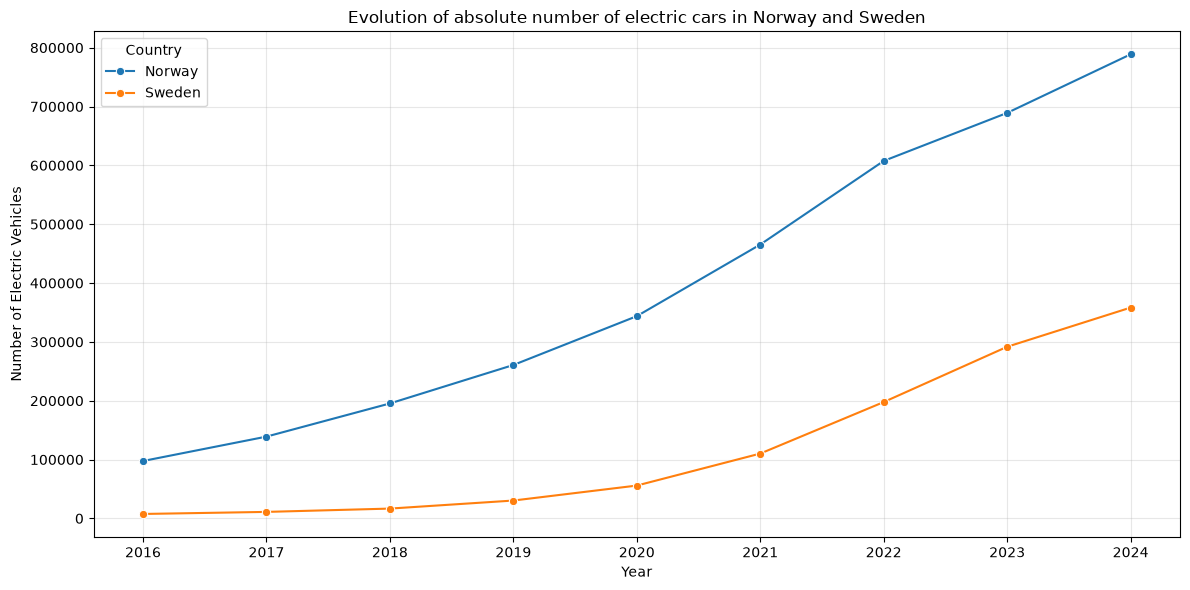

In [545]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_cars_final_N_S,
    x="Year",
    y="EV_cars",
    hue="Country",
    marker="o"
)

plt.title("Evolution of absolute number of electric cars in Norway and Sweden")
plt.xlabel("Year")
plt.ylabel("Number of Electric Vehicles")
plt.grid(True, alpha=0.3)
plt.legend(title="Country")
plt.tight_layout()
plt.show()

### Relative amount of electric cars in EU countries (share of EV)

In [546]:
# 1. Create one box plot per year
fig = px.box(
    df_cars_final,
    x="Year",
    y="EV_share_pct",
    labels={
        "Year": "Year",
        "EV_share_pct": "Share of electric vehicles"
    },
    title="Distribution of the share of EVs Across EU Countries by Year",
    points=False
)


# Style box plots, display the mean,
# and disable native box-plot hover labels
fig.update_traces(
    selector=dict(type="box"),
    showlegend=False,
    fillcolor="rgba(100, 100, 100, 0.20)",
    line_color="rgba(180, 180, 180, 0.85)",
    boxmean=True,
    hoveron="points",
    hoverinfo="skip"
)


# 2. Add one coloured and interactive point per country and year
for country in countries:
    country_data = df_cars_final[
        df_cars_final["Country"] == country
    ]

    fig.add_trace(
        go.Scatter(
            x=country_data["Year"],
            y=country_data["EV_share_pct"],
            mode="markers",
            name=country,
            marker=dict(
                color=country_colors[country],
                size=8,
                opacity=0.8
            ),
            text=country_data["Country"],
            hovertemplate=(
                "<b>%{text}</b><br>"
                "Year: %{x}<br>"
                "EV_share: %{y:,.0f}"
                "<extra></extra>"
            ),
            showlegend=False
        )
    )


# 3. Calculate descriptive statistics for each year
yearly_stats = (
    df_cars_final
    .groupby("Year")["EV_share_pct"]
    .agg(
        Minimum="min",
        Q1=lambda x: x.quantile(0.25),
        Median="median",
        Mean="mean",
        Q3=lambda x: x.quantile(0.75),
        Maximum="max"
    )
    .reset_index()
)


# Place the invisible statistics trigger above each year's maximum value
y_range = (
    df_cars_final["EV_share_pct"].max()
    - df_cars_final["EV_share_pct"].min()
)

yearly_stats["hover_y"] = (
    yearly_stats["Maximum"] + 0.04 * y_range
)


# 4. Add one invisible but hoverable marker per year.
# Hover near the top of a year to see its statistical summary.
fig.add_trace(
    go.Scatter(
        x=yearly_stats["Year"],
        y=yearly_stats["hover_y"],
        mode="markers",
        marker=dict(
            size=28,
            color="rgba(0,0,0,0)"
        ),
        customdata=yearly_stats[
            ["Minimum", "Q1", "Median", "Mean", "Q3", "Maximum"]
        ].to_numpy(),
        hovertemplate=(
            "<b>Year: %{x}</b><br><br>"
            "Maximum: %{customdata[5]:,.0f}<br>"
            "Q3: %{customdata[4]:,.0f}<br>"
            "Mean: %{customdata[3]:,.0f}</b><br>"
            "Median: %{customdata[2]:,.0f}<br>"
            "Q1: %{customdata[1]:,.0f}<br>"
            "Minimum: %{customdata[0]:,.0f}"
            "<extra></extra>"
        ),
        showlegend=False
    )
)


# Improve the chart's layout and interaction
fig.update_layout(
    xaxis=dict(
        title="Year",
        type="category"
    ),
    yaxis=dict(
        title="Share of electric vehicles (in %)",
        separatethousands=True
    ),
    hovermode="closest",
    template="plotly_white"
)


fig.show()

In [547]:
country_to_iso3 = {
    "Austria": "AUT",
    "Belgium": "BEL",
    "Bulgaria": "BGR",
    "Croatia": "HRV",
    "Cyprus": "CYP",
    "Czechia": "CZE",
    "Denmark": "DNK",
    "Estonia": "EST",
    "Finland": "FIN",
    "France": "FRA",
    "Germany": "DEU",
    "Greece": "GRC",
    "Hungary": "HUN",
    "Ireland": "IRL",
    "Italy": "ITA",
    "Latvia": "LVA",
    "Lithuania": "LTU",
    "Luxembourg": "LUX",
    "Malta": "MLT",
    "Netherlands": "NLD",
    "Poland": "POL",
    "Portugal": "PRT",
    "Romania": "ROU",
    "Slovakia": "SVK",
    "Slovenia": "SVN",
    "Spain": "ESP",
    "Sweden": "SWE",
    "Norway": "NOR"
}

df_cars_final["ISO3"] = df_cars_final["Country"].map(country_to_iso3)

df_cars_final = df_cars_final[
    ['Country', 'ISO3', 'Year', 'EV_cars', 'Total_cars', 'EV_share_pct']
]

df_cars_final.head()

,Country,ISO3,Year,EV_cars,Total_cars,EV_share_pct
0,Austria,AUT,2016,9073.0,4821557.0,0.188176
1,Austria,AUT,2017,14618.0,4898578.0,0.298413
2,Austria,AUT,2018,20831.0,4978852.0,0.418390
3,Austria,AUT,2019,29523.0,5039548.0,0.585826
4,Austria,AUT,2020,44507.0,5091827.0,0.874087


In [548]:
map_cars_animated = px.choropleth(
    df_cars_final,                                 # dataframe as argument
    locations="ISO3",
    locationmode="ISO-3",               # location method
    color="EV_share_pct",                       # color countries with altruism value
    animation_frame="Year",
    scope="europe",
    range_color=(0, df_cars_final["EV_share_pct"].max()),
    color_continuous_scale=px.colors.sequential.Plasma,   # choice of colors
    labels={"EV_share": "EV Share"},
)
map_cars_animated.update_layout( 
    title={                                # Add a title, centered on top
        'text': "Evolution of EV Share (%) per Country (2016-2024)",
        'y':0.9,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'})

map_cars_animated.show()

In [549]:
map_cars_animated_no_Norway = px.choropleth(
    df_cars_final [df_cars_final["Country"] != "Norway"],                                 # dataframe as argument
    locations="ISO3",
    locationmode="ISO-3",                # location method
    color="EV_share_pct",                       # color countries with altruism value
    animation_frame="Year",
    scope="europe",
    range_color=(0, df_cars_final.loc[df_cars_final["Country"] != "Norway", "EV_share_pct"].max()),
    color_continuous_scale=px.colors.sequential.Plasma,   # choice of colors
    labels={"EV_share": "EV Share"},
)
map_cars_animated_no_Norway.update_layout( 
    title={                                # Add a title, centered on top
        'text': "Evolution of EV Share (%) per Country excluding Norway (2016-2024)",
        'y':0.9,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'})
map_cars_animated_no_Norway.show()

### Relative amount of electric cars in Norway and Sweden (share of EV)

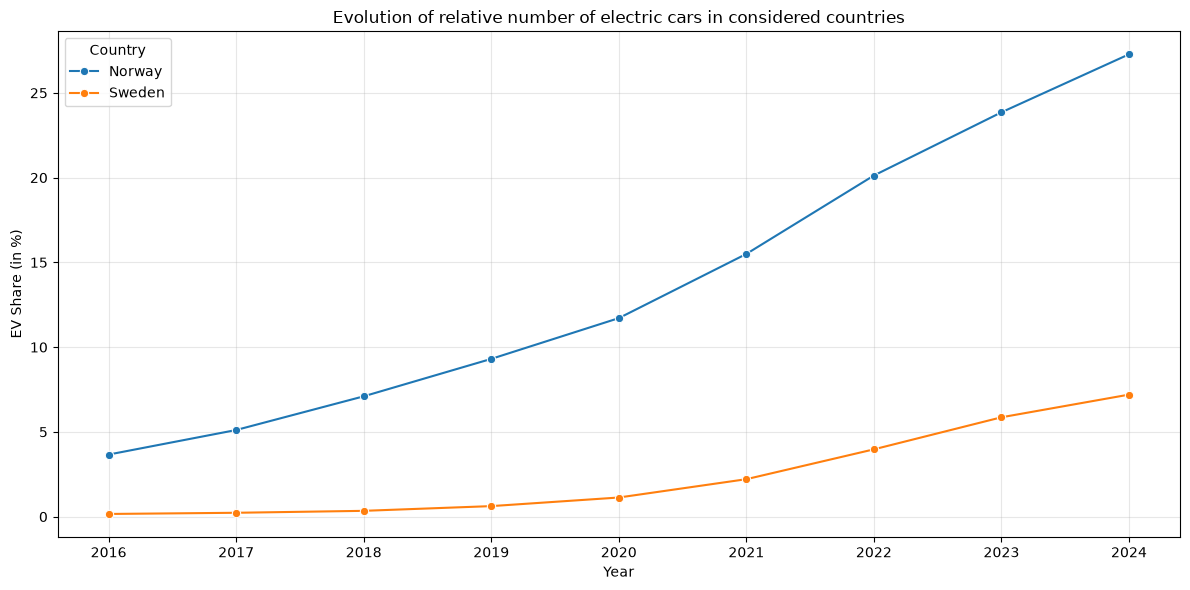

In [550]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_cars_final_N_S,
    x="Year",
    y="EV_share_pct",
    hue="Country",
    marker="o"
)

plt.title("Evolution of relative number of electric cars in considered countries")
plt.xlabel("Year")
plt.ylabel("EV Share (in %)")
plt.grid(True, alpha=0.3)
plt.legend(title="Country")
plt.tight_layout()
plt.show()

# Data Cleaning and univariate analysis for NOx emissions

### Load Data 

You need to download the following files :  
- Evolution of emissions of pollutants in countries : https://www.dropbox.com/scl/fi/za4x3lhjip10bxeanznh1/Emissions.csv?rlkey=duyun7b8bxs8lkxurxx4890qw&st=l58id7do&dl=0
- Evolution of population in countries : https://www.dropbox.com/scl/fi/v6p0gg3hes15e6pfwmjdl/Population.csv?rlkey=mljxr5nimv4sxmjkww1wgm47a&st=8x74mhyk&dl=0

In [551]:
df = pd.read_csv("Emissions.csv",sep="\t",low_memory=False)

df.head()

,countryCode,country,pollutantName,sectorCode,year,value,unit,notation,parentSectorCode,sectorName
0,AT,Austria,As,1B1b,2017,NaN,t,NR,NATIONAL TOTAL,Fugitive emission from solid fuels: Solid fuel...
1,AT,Austria,As,1B1b,2018,NaN,t,NR,NATIONAL TOTAL,Fugitive emission from solid fuels: Solid fuel...
2,AT,Austria,As,1B1b,2019,NaN,t,NR,NATIONAL TOTAL,Fugitive emission from solid fuels: Solid fuel...
3,AT,Austria,As,1B1b,2020,NaN,t,NR,NATIONAL TOTAL,Fugitive emission from solid fuels: Solid fuel...
4,AT,Austria,As,1B1b,2021,NaN,t,NR,NATIONAL TOTAL,Fugitive emission from solid fuels: Solid fuel...


### Restructure dataset

In [552]:
df.shape

(4511772, 10)

In [553]:
df.columns

Index(['countryCode', 'country', 'pollutantName', 'sectorCode', 'year',
       'value', 'unit', 'notation', 'parentSectorCode', 'sectorName'],
      dtype='str')

In [554]:
useful_cols = ["country","pollutantName","year","value","unit","sectorName"]

df_bis = pd.read_csv("Emissions.csv",sep="\t",usecols=useful_cols,low_memory=False)

df_bis.head()

,country,pollutantName,year,value,unit,sectorName
0,Austria,As,2017,NaN,t,Fugitive emission from solid fuels: Solid fuel...
1,Austria,As,2018,NaN,t,Fugitive emission from solid fuels: Solid fuel...
2,Austria,As,2019,NaN,t,Fugitive emission from solid fuels: Solid fuel...
3,Austria,As,2020,NaN,t,Fugitive emission from solid fuels: Solid fuel...
4,Austria,As,2021,NaN,t,Fugitive emission from solid fuels: Solid fuel...


### Looking only at NOx emissions

In [555]:
df_bis["pollutantName"].dropna().unique()

<StringArray>
[                        'As',                         'BC',
            'Benzo(a) Pyrene',      'Benzo(b) Fluoranthene',
      'benzo(k) Fluoranthene',                         'Cd',
                         'CO',   'Indeno (1,2,3-cd) Pyrene',
                        'NOx',                      'PM2.5',
                         'Zn',                         'Cr',
                         'Pb',                         'Se',
                        'NH3',                       'PCBs',
                         'Cu',                         'Ni',
                        'SOx', 'PCDD/PCDF (dioxins/furans)',
                      'NMVOC',                        'HCB',
                 'Total PAHs',                       'PM10',
                        'TSP',                         'Hg',
                    'Biomass',              'Gaseous Fuels',
               'Liquid Fuels',                'Other Fuels',
                'Solid Fuels']
Length: 31, dtype: str

In [556]:
df_NOx = df_bis[df_bis["pollutantName"].str.upper().eq("NOX")].copy()

df_NOx.head()

,country,pollutantName,year,value,unit,sectorName
25945,Austria,NOx,2023,NaN,kt,Biological treatment of waste - Solid waste di...
25946,Austria,NOx,2024,NaN,kt,Biological treatment of waste - Solid waste di...
25947,Austria,NOx,1987,NaN,kt,Biological treatment of waste - Composting
25948,Austria,NOx,1988,NaN,kt,Biological treatment of waste - Composting
25949,Austria,NOx,1989,NaN,kt,Biological treatment of waste - Composting


### Removing rows with no values for NOx emissions

In [557]:
df_NOx = df_NOx.dropna(subset=["value"]).copy()

df_NOx.head()

,country,pollutantName,year,value,unit,sectorName
26544,Austria,NOx,1990,0.019140,kt,Municipal waste incineration
26545,Austria,NOx,1991,0.019140,kt,Municipal waste incineration
26887,Austria,NOx,1987,0.017732,kt,Industrial waste incineration
26888,Austria,NOx,1988,0.017732,kt,Industrial waste incineration
26889,Austria,NOx,1989,0.017732,kt,Industrial waste incineration


### Considering values after 2016 (same as data from cars)

In [558]:
df_NOx = df_NOx[
    (df_NOx["year"] >= 2016)
].copy()

df_NOx.head()

,country,pollutantName,year,value,unit,sectorName
26916,Austria,NOx,2016,0.00403,kt,Industrial waste incineration
26917,Austria,NOx,2017,0.00403,kt,Industrial waste incineration
26918,Austria,NOx,2018,0.00403,kt,Industrial waste incineration
26919,Austria,NOx,2019,0.00403,kt,Industrial waste incineration
26920,Austria,NOx,2020,0.00403,kt,Industrial waste incineration


### Considering total emissions and road transport emissions in countries

In [559]:
df_NOx["sectorName"].unique()

<StringArray>
[                                                      'Industrial waste incineration',
                                                         'Clinical waste incineration',
                                                                           'Cremation',
                                                               'Open burning of waste',
                                                                         'Adjustments',
   'National total for compliance assessment  (please specify all details in the IIR)',
                        'National total for the entire territory (based on fuel sold)',
                                                        'Municipal waste incineration',
                                              'Public electricity and heat production',
                                                                  'Petroleum refining',
 ...
                                                      'Crop residues applied to soils',
 'Other (incl

For NOx emissions within the countries, we will use :   
- 'National total for the entire territory (based on fuel sold)'.
- 'Road transport: Passenger cars'.   

In order to compare total emissions to passenger car emissions within countries.

Meaning of “based on fuel sold” : It means that emissions from fuel combustion are attributed to countries when the relevant fuel was sold in it, using the fuel quantity and pollutant-specific emission factors.

In [560]:
total_sector = "National total for the entire territory (based on fuel sold)"

df_NOx_total = df_NOx[df_NOx["sectorName"].eq(total_sector)].copy()

df_NOx_total.head()

,country,pollutantName,year,value,unit,sectorName
30470,Austria,NOx,2016,188.932,kt,National total for the entire territory (based...
30567,Austria,NOx,2017,178.469,kt,National total for the entire territory (based...
30568,Austria,NOx,2018,165.365,kt,National total for the entire territory (based...
30569,Austria,NOx,2019,155.719,kt,National total for the entire territory (based...
30570,Austria,NOx,2020,133.270,kt,National total for the entire territory (based...


In [561]:
road_transport = "Road transport: Passenger cars"

df_NOx_transport = df_NOx[df_NOx["sectorName"].eq(road_transport)].copy()

df_NOx_transport.head()

,country,pollutantName,year,value,unit,sectorName
158928,Austria,NOx,2016,60.8992,kt,Road transport: Passenger cars
158929,Austria,NOx,2017,57.7763,kt,Road transport: Passenger cars
158930,Austria,NOx,2018,53.5562,kt,Road transport: Passenger cars
158931,Austria,NOx,2019,48.5261,kt,Road transport: Passenger cars
158932,Austria,NOx,2020,36.0862,kt,Road transport: Passenger cars


### Filtering countries

In [562]:
df_NOx_total["country"].unique()

<StringArray>
[      'Austria',       'Belgium',      'Bulgaria',        'Cyprus',
       'Czechia',       'Germany',       'Denmark',       'Estonia',
         'Spain',       'Finland',        'France',        'Greece',
       'Croatia',       'Hungary',       'Ireland',         'Italy',
     'Lithuania',    'Luxembourg',        'Latvia',         'Malta',
   'Netherlands',        'Poland',      'Portugal',       'Romania',
        'Sweden',      'Slovenia',      'Slovakia',   'Switzerland',
       'Iceland', 'Liechtenstein',        'Norway',       'Türkiye',
         'EEA32',          'EU27']
Length: 34, dtype: str

In [563]:
df_NOx_total_clean = (df_NOx_total[df_NOx_total["country"].isin(EU_countries)]
                .sort_values(["country", "year"], ascending=[True, True]).reset_index(drop=True))

df_NOx_total_clean_N_S = (df_NOx_total[df_NOx_total["country"].isin(considered_countries)]
                .sort_values(["country", "year"], ascending=[True, True]).reset_index(drop=True))

df_NOx_total_clean.head()

,country,pollutantName,year,value,unit,sectorName
0,Austria,NOx,2016,188.932,kt,National total for the entire territory (based...
1,Austria,NOx,2017,178.469,kt,National total for the entire territory (based...
2,Austria,NOx,2018,165.365,kt,National total for the entire territory (based...
3,Austria,NOx,2019,155.719,kt,National total for the entire territory (based...
4,Austria,NOx,2020,133.270,kt,National total for the entire territory (based...


In [564]:
df_NOx_transport_clean = (df_NOx_transport[df_NOx_transport["country"].isin(EU_countries)]
                .sort_values(["country", "year"], ascending=[True, True]).reset_index(drop=True))

df_NOx_transport_clean_N_S = (df_NOx_transport[df_NOx_transport["country"].isin(considered_countries)]
                .sort_values(["country", "year"], ascending=[True, True]).reset_index(drop=True))

df_NOx_transport_clean.head()

,country,pollutantName,year,value,unit,sectorName
0,Austria,NOx,2016,60.8992,kt,Road transport: Passenger cars
1,Austria,NOx,2017,57.7763,kt,Road transport: Passenger cars
2,Austria,NOx,2018,53.5562,kt,Road transport: Passenger cars
3,Austria,NOx,2019,48.5261,kt,Road transport: Passenger cars
4,Austria,NOx,2020,36.0862,kt,Road transport: Passenger cars


### Univariate Analysis

#### Total emissions of NOx in EU countries (all sectors)

In [565]:
# 1. Create one box plot per year
fig = px.box(
    df_NOx_total_clean,
    x="year",
    y="value",
    labels={
        "year": "Year",
        "value": "Total NOx emissions"
    },
    title="Distribution of the total NOx emissions across EU Countries by Year",
    points=False
)

# Style box plots, display the mean and disable native box-plot hover labels
fig.update_traces(
    selector=dict(type="box"),
    showlegend=False,
    fillcolor="rgba(100, 100, 100, 0.20)",
    line_color="rgba(180, 180, 180, 0.85)",
    boxmean=True,
    hoveron="points",
    hoverinfo="skip"
)

# 2. Add one coloured and interactive point per country and year
for country in countries:
    country_data = df_NOx_total_clean[
        df_NOx_total_clean["country"] == country
    ]

    fig.add_trace(
        go.Scatter(
            x=country_data["year"],
            y=country_data["value"],
            mode="markers",
            name=country,
            marker=dict(
                color=country_colors[country],
                size=8,
                opacity=0.8
            ),
            text=country_data["country"],
            hovertemplate=(
                "<b>%{text}</b><br>"
                "year: %{x}<br>"
                "value: %{y:,.0f}"
                "<extra></extra>"
            ),
            showlegend=False
        )
    )

# 3. Calculate descriptive statistics for each year
yearly_stats = (
    df_NOx_total_clean
    .groupby("year")["value"]
    .agg(
        Minimum="min",
        Q1=lambda x: x.quantile(0.25),
        Median="median",
        Mean="mean",
        Q3=lambda x: x.quantile(0.75),
        Maximum="max"
    )
    .reset_index()
)

# Place the invisible statistics trigger above each year's maximum value
y_range = (
    df_NOx_total_clean["value"].max()
    - df_NOx_total_clean["value"].min()
)

yearly_stats["hover_y"] = (
    yearly_stats["Maximum"] + 0.04 * y_range
)

# 4. Add one invisible but hoverable marker per year.
# Hover near the top of a year to see its statistical summary.
fig.add_trace(
    go.Scatter(
        x=yearly_stats["year"],
        y=yearly_stats["hover_y"],
        mode="markers",
        marker=dict(
            size=28,
            color="rgba(0,0,0,0)"
        ),
        customdata=yearly_stats[
            ["Minimum", "Q1", "Median", "Mean", "Q3", "Maximum"]
        ].to_numpy(),
        hovertemplate=(
            "<b>Year: %{x}</b><br><br>"
            "Maximum: %{customdata[5]:,.0f}<br>"
            "Q3: %{customdata[4]:,.0f}<br>"
            "Mean: %{customdata[3]:,.0f}</b><br>"
            "Median: %{customdata[2]:,.0f}<br>"
            "Q1: %{customdata[1]:,.0f}<br>"
            "Minimum: %{customdata[0]:,.0f}"
            "<extra></extra>"
        ),
        showlegend=False
    )
)

# Improve the chart's layout and interaction
fig.update_layout(
    xaxis=dict(
        title="Year",
        type="category"
    ),
    yaxis=dict(
        title="Total NOx emissions (in kt)",
        separatethousands=True
    ),
    hovermode="closest",
    template="plotly_white"
)

fig.show()

#### Total emissions of NOx in Norway and Sweden (all sectors)

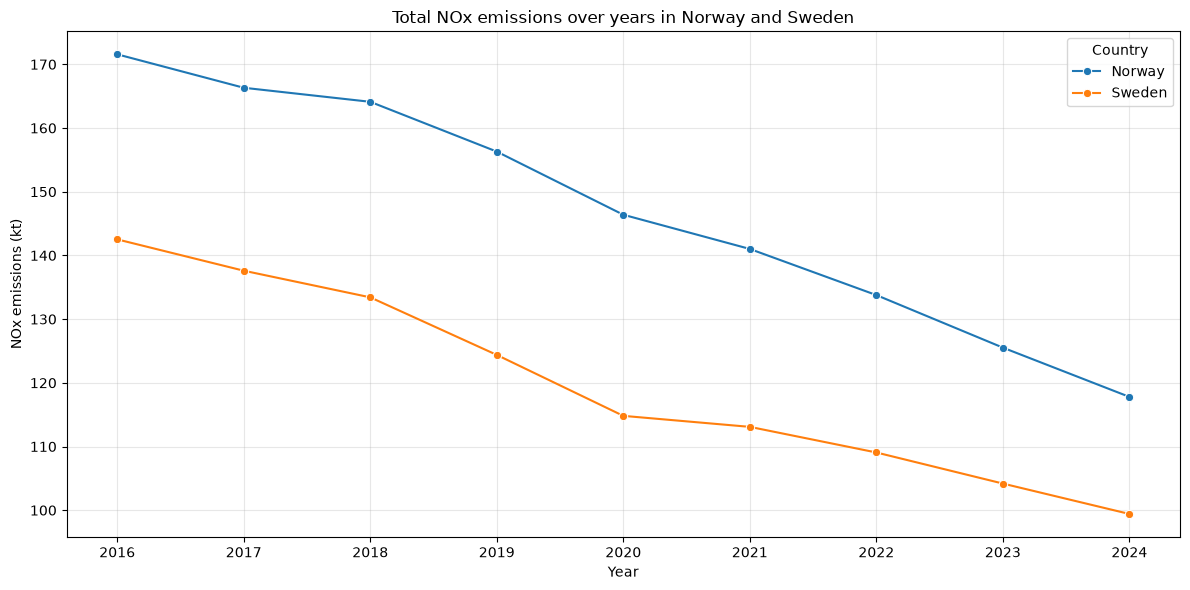

In [566]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_NOx_total_clean_N_S,
    x="year",
    y="value",
    hue="country",
    marker="o"
)

plt.title("Total NOx emissions over years in Norway and Sweden")
plt.xlabel("Year")
plt.ylabel("NOx emissions (kt)")
plt.grid(True, alpha=0.3)
plt.legend(title="Country")
plt.tight_layout()
plt.show()

#### Road transport related NOx emissions in EU countries

In [567]:
# 1. Create one box plot per year
fig = px.box(
    df_NOx_transport_clean,
    x="year",
    y="value",
    labels={
        "year": "Year",
        "value": "Road transport related NOx emissions"
    },
    title="Distribution of the road transport related NOx emissions across EU Countries by Year",
    points=False
)

# Style box plots, display the mean,
# and disable native box-plot hover labels
fig.update_traces(
    selector=dict(type="box"),
    showlegend=False,
    fillcolor="rgba(100, 100, 100, 0.20)",
    line_color="rgba(180, 180, 180, 0.85)",
    boxmean=True,
    hoveron="points",
    hoverinfo="skip"
)

# 2. Add one coloured and interactive point per country and year
for country in countries:
    country_data = df_NOx_transport_clean[
        df_NOx_transport_clean["country"] == country
    ]

    fig.add_trace(
        go.Scatter(
            x=country_data["year"],
            y=country_data["value"],
            mode="markers",
            name=country,
            marker=dict(
                color=country_colors[country],
                size=8,
                opacity=0.8
            ),
            text=country_data["country"],
            hovertemplate=(
                "<b>%{text}</b><br>"
                "year: %{x}<br>"
                "value: %{y:,.0f}"
                "<extra></extra>"
            ),
            showlegend=False
        )
    )

# 3. Calculate descriptive statistics for each year
yearly_stats = (
    df_NOx_transport_clean
    .groupby("year")["value"]
    .agg(
        Minimum="min",
        Q1=lambda x: x.quantile(0.25),
        Median="median",
        Mean="mean",
        Q3=lambda x: x.quantile(0.75),
        Maximum="max"
    )
    .reset_index()
)

# Place the invisible statistics trigger above each year's maximum value
y_range = (
    df_NOx_transport_clean["value"].max()
    - df_NOx_transport_clean["value"].min()
)

yearly_stats["hover_y"] = (
    yearly_stats["Maximum"] + 0.04 * y_range
)

# 4. Add one invisible but hoverable marker per year.
# Hover near the top of a year to see its statistical summary.
fig.add_trace(
    go.Scatter(
        x=yearly_stats["year"],
        y=yearly_stats["hover_y"],
        mode="markers",
        marker=dict(
            size=28,
            color="rgba(0,0,0,0)"
        ),
        customdata=yearly_stats[
            ["Minimum", "Q1", "Median", "Mean", "Q3", "Maximum"]
        ].to_numpy(),
        hovertemplate=(
            "<b>Year: %{x}</b><br><br>"
            "Maximum: %{customdata[5]:,.0f}<br>"
            "Q3: %{customdata[4]:,.0f}<br>"
            "Mean: %{customdata[3]:,.0f}</b><br>"
            "Median: %{customdata[2]:,.0f}<br>"
            "Q1: %{customdata[1]:,.0f}<br>"
            "Minimum: %{customdata[0]:,.0f}"
            "<extra></extra>"
        ),
        showlegend=False
    )
)

# Improve the chart's layout and interaction
fig.update_layout(
    xaxis=dict(
        title="Year",
        type="category"
    ),
    yaxis=dict(
        title="Road transport related NOx emissions (in kt)",
        separatethousands=True
    ),
    hovermode="closest",
    template="plotly_white"
)

fig.show()

#### Road transport related NOx emissions in Norway and Sweden

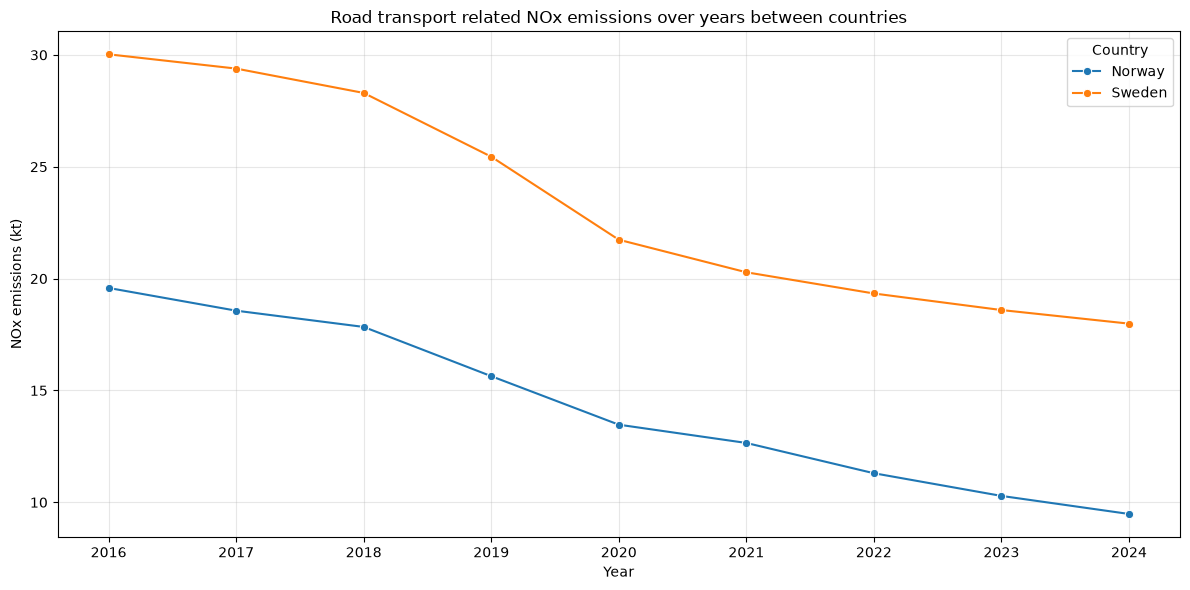

In [568]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_NOx_transport_clean_N_S,
    x="year",
    y="value",
    hue="country",
    marker="o"
)

plt.title("Road transport related NOx emissions over years between countries")
plt.xlabel("Year")
plt.ylabel("NOx emissions (kt)")
plt.grid(True, alpha=0.3)
plt.legend(title="Country")
plt.tight_layout()
plt.show()

#### Share of NOx emissions related to road transport in EU countries

In [569]:
final_NOx_df = (
    df_NOx_transport_clean
    .groupby(["country", "year"], as_index=False)["value"]
    .sum()
    .rename(columns={
        "value": "Road transport emissions (kt)"
    })
    .merge(
        df_NOx_total_clean[
            ["country", "year", "value"]
        ].rename(columns={
            "value": "Total NOx emissions (kt)"
        }),
        on=["country", "year"],
        how="inner"
    )
    .assign(
        Road_transport_share_pct=lambda x: (
            x["Road transport emissions (kt)"]
            / x["Total NOx emissions (kt)"]
            * 100
        )
    )
)

final_NOx_df_N_S = final_NOx_df[
    final_NOx_df["country"].isin(["Norway", "Sweden"])
].copy()

final_NOx_df.head()

,country,year,Road transport emissions (kt),Total NOx emissions (kt),Road_transport_share_pct
0,Austria,2016,60.8992,188.932,32.233396
1,Austria,2017,57.7763,178.469,32.373297
2,Austria,2018,53.5562,165.365,32.386660
3,Austria,2019,48.5261,155.719,31.162607
4,Austria,2020,36.0862,133.270,27.077512


In [570]:
# 1. Create one box plot per year
fig = px.box(
    final_NOx_df,
    x="year",
    y="Road_transport_share_pct",
    labels={
        "year": "Year",
        "Road_transport_share_pct": "Share of the road transport in NOx emissions across EU Countries by Year"
    },
    title="Share of the road transport in NOx emissions across EU Countries by Year",
    points=False
)

# Style box plots, display the mean and disable native box-plot hover labels
fig.update_traces(
    selector=dict(type="box"),
    showlegend=False,
    fillcolor="rgba(100, 100, 100, 0.20)",
    line_color="rgba(180, 180, 180, 0.85)",
    boxmean=True,
    hoveron="points",
    hoverinfo="skip"
)

# 2. Add one coloured and interactive point per country and year
for country in countries:
    country_data = final_NOx_df[
        final_NOx_df["country"] == country
    ]

    fig.add_trace(
        go.Scatter(
            x=country_data["year"],
            y=country_data["Road_transport_share_pct"],
            mode="markers",
            name=country,
            marker=dict(
                color=country_colors[country],
                size=8,
                opacity=0.8
            ),
            text=country_data["country"],
            hovertemplate=(
                "<b>%{text}</b><br>"
                "year: %{x}<br>"
                "Road_transport_share_pct: %{y:,.0f}"
                "<extra></extra>"
            ),
            showlegend=False
        )
    )

# 3. Calculate descriptive statistics for each year
yearly_stats = (
    final_NOx_df
    .groupby("year")["Road_transport_share_pct"]
    .agg(
        Minimum="min",
        Q1=lambda x: x.quantile(0.25),
        Median="median",
        Mean="mean",
        Q3=lambda x: x.quantile(0.75),
        Maximum="max"
    )
    .reset_index()
)

# Place the invisible statistics trigger above each year's maximum value
y_range = (
    final_NOx_df["Road_transport_share_pct"].max()
    - final_NOx_df["Road_transport_share_pct"].min()
)

yearly_stats["hover_y"] = (
    yearly_stats["Maximum"] + 0.04 * y_range
)

# 4. Add one invisible but hoverable marker per year.
# Hover near the top of a year to see its statistical summary.
fig.add_trace(
    go.Scatter(
        x=yearly_stats["year"],
        y=yearly_stats["hover_y"],
        mode="markers",
        marker=dict(
            size=28,
            color="rgba(0,0,0,0)"
        ),
        customdata=yearly_stats[
            ["Minimum", "Q1", "Median", "Mean", "Q3", "Maximum"]
        ].to_numpy(),
        hovertemplate=(
            "<b>Year: %{x}</b><br><br>"
            "Maximum: %{customdata[5]:,.0f}<br>"
            "Q3: %{customdata[4]:,.0f}<br>"
            "Mean: %{customdata[3]:,.0f}</b><br>"
            "Median: %{customdata[2]:,.0f}<br>"
            "Q1: %{customdata[1]:,.0f}<br>"
            "Minimum: %{customdata[0]:,.0f}"
            "<extra></extra>"
        ),
        showlegend=False
    )
)

# Improve the chart's layout and interaction
fig.update_layout(
    xaxis=dict(
        title="Year",
        type="category"
    ),
    yaxis=dict(
        title="Share of the road transport in NOx emissions (in %)",
        separatethousands=True
    ),
    hovermode="closest",
    template="plotly_white"
)

fig.show()

#### Share of NOx emissions related to road transport in Norway and Sweden

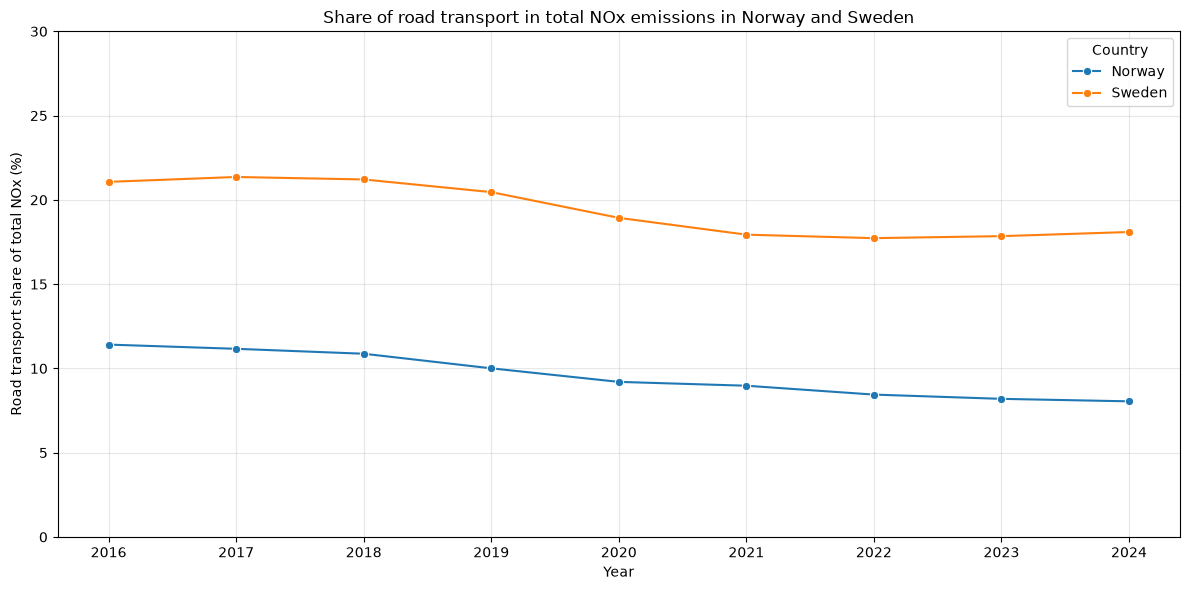

In [571]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=final_NOx_df_N_S,
    x="year",
    y="Road_transport_share_pct",
    hue="country",
    marker="o"
)

plt.title("Share of road transport in total NOx emissions in Norway and Sweden")
plt.xlabel("Year")
plt.ylabel("Road transport share of total NOx (%)")
plt.ylim(0, 30)
plt.grid(True, alpha=0.3)
plt.legend(title="Country")
plt.tight_layout()
plt.show()

### Cumulative NOx emissions over years in EU countries

In [572]:
# -------------------------------------------------------
# 1. Aggregate annual emissions over the 2016–2024 period
# -------------------------------------------------------
total_by_country = (
    df_NOx_total_clean
    .groupby("country", as_index=False)["value"]
    .sum()
    .rename(columns={"value": "total_nox_kt"})
)

road_by_country = (
    df_NOx_transport_clean
    .groupby("country", as_index=False)["value"]
    .sum()
    .rename(columns={"value": "road_nox_kt"})
)

# Merge the two datasets and preserve every country from total emissions
df_nox_comparison = (
    total_by_country
    .merge(road_by_country, on="country", how="left")
    .fillna({"road_nox_kt": 0})
)

# Optional safety check: road transport should not exceed total emissions
df_nox_comparison["road_nox_kt"] = (
    df_nox_comparison[["road_nox_kt", "total_nox_kt"]]
    .min(axis=1)
)

# Correct calculation of the share of road-transport NOx emissions
df_nox_comparison["road_share_pct"] = np.where(
    df_nox_comparison["total_nox_kt"] > 0,
    (
        df_nox_comparison["road_nox_kt"]
        / df_nox_comparison["total_nox_kt"]
        * 100
    ),
    0
)

# Countries ordered from the largest to the smallest emitter
df_nox_comparison = (
    df_nox_comparison
    .sort_values("total_nox_kt", ascending=False)
    .reset_index(drop=True)
)

# -------------------------------------------------------
# 2. Build a color scale by country rank
# -------------------------------------------------------
# First country (highest total NOx): dark red
# Last country (lowest total NOx): pale yellow
country_colors = sample_colorscale(
    colorscale=[
        [0.00, "#8B1A1A"],  # dark red
        [0.35, "#C83C23"],  # red-orange
        [0.65, "#F28E2B"],  # orange
        [1.00, "#F8D878"],  # pale yellow
    ],
    samplepoints=len(df_nox_comparison)
)

# Slightly darker shade for road transport, one shade per country
road_colors = sample_colorscale(
    colorscale=[
        [0.00, "#4E0A0A"],  # dark burgundy
        [0.35, "#8F1E14"],  # dark red
        [0.65, "#C65B11"],  # dark orange
        [1.00, "#C9A52A"],  # dark yellow
    ],
    samplepoints=len(df_nox_comparison)
)

# Data used by the interactive hover box
customdata = df_nox_comparison[
    ["country", "total_nox_kt", "road_nox_kt", "road_share_pct"]
].to_numpy()

# -------------------------------------------------------
# 3. Create chart
# -------------------------------------------------------
fig = go.Figure()

# Total cumulative emissions: wider, light outer bar
fig.add_trace(
    go.Bar(
        x=df_nox_comparison["country"],
        y=df_nox_comparison["total_nox_kt"],
        width=0.78,
        marker=dict(
            color=country_colors,
            line=dict(color="rgba(77, 56, 45, 0.55)", width=0.7),
        ),
        customdata=customdata,
        hovertemplate=(
            "<b>%{customdata[0]}</b><br>"
            "Total cumulative NOx emissions: %{customdata[1]:,.1f} kt<br>"
            "Cumulative road-transport NOx emissions: %{customdata[2]:,.1f} kt<br>"
            "Road transport share: %{customdata[3]:.1f}%"
            "<extra></extra>"
        ),
        showlegend=False,
    )
)

# Road-transport emissions: narrower and darker inner bar
fig.add_trace(
    go.Bar(
        x=df_nox_comparison["country"],
        y=df_nox_comparison["road_nox_kt"],
        width=0.48,
        marker=dict(
            color=road_colors,
            line=dict(color="rgba(77, 56, 45, 0.65)", width=0.7),
        ),
        customdata=customdata,
        hovertemplate=(
            "<b>%{customdata[0]}</b><br>"
            "Total cumulative NOx emissions: %{customdata[1]:,.1f} kt<br>"
            "Cumulative road-transport NOx emissions: %{customdata[2]:,.1f} kt<br>"
            "Road transport share: %{customdata[3]:.1f}%"
            "<extra></extra>"
        ),
        showlegend=False,
    )
)

# -------------------------------------------------------
# 4. Style
# -------------------------------------------------------
fig.update_layout(
    template="plotly_white",
    barmode="overlay",
    bargap=0.12,
    showlegend=False,

    title=dict(
        text="Cumulative NOx emissions in EU countries (2016–2024)",
        x=0.04,
        xanchor="left",
        font=dict(
            family="Arial, sans-serif",
            size=23,          # reduced title size
            color="#2F4565",
        ),
    ),

    xaxis=dict(
        title=None,
        showticklabels=False,
        showgrid=False,
        zeroline=False,
        fixedrange=True,
    ),

    yaxis=dict(
        title=dict(
            text="Cumulative NOx emissions (kt)",
            font=dict(
                family="Arial, sans-serif",
                size=19,
                color="#2F4565",
            ),
        ),
        tickfont=dict(
            family="Arial, sans-serif",
            size=14,
            color="#2F4565",
        ),
        gridcolor="rgba(210, 218, 230, 0.70)",
        zeroline=False,
        fixedrange=True,
    ),

    hoverlabel=dict(
        bgcolor="white",
        bordercolor="#8D99A8",
        font=dict(
            family="Arial, sans-serif",
            size=14,
            color="#263B59",
        ),
        align="left",
    ),

    paper_bgcolor="white",
    plot_bgcolor="white",
    margin=dict(l=95, r=45, t=100, b=55),
    height=650,
)

fig.show()

#### Taking population into account

In [573]:
df = pd.read_csv("Population.csv", sep=";", low_memory=False)

df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107995.0,108785.0,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750491370.0,769280888.0,788844284.0,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0,43844111.0,NaN
3,Africa Western and Central,AFW,"Population, total",SP.POP.TOTL,97630925.0,99706674.0,101854756.0,104089175.0,106384410.0,108754449.0,...,440150152.0,451395343.0,462522286.0,473687685.0,484978794.0,496366058.0,508318102.0,520655398.0,532809933.0,NaN
4,Angola,AGO,"Population, total",SP.POP.TOTL,5231654.0,5301583.0,5354310.0,5408320.0,5464187.0,5521981.0,...,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0,39040039.0,NaN


In [574]:
df.shape

(265, 71)

### Restructure dataset

In [575]:
df.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023', '2024', '2025', 'Unnamed: 70'],
      dtype='str')

In [576]:
year_cols = [str(year) for year in range(2016, 2025)]

useful_cols = ["Country Name"] + year_cols

df_bis = pd.read_csv("Population.csv",sep=";",usecols=useful_cols,low_memory=False)

df_bis.head()

,Country Name,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,108727.0,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107995.0
1,Africa Eastern and Southern,623369401.0,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750491370.0,769280888.0
2,Afghanistan,34700612.0,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0
3,Africa Western and Central,428797338.0,440150152.0,451395343.0,462522286.0,473687685.0,484978794.0,496366058.0,508318102.0,520655398.0
4,Angola,29183070.0,30234839.0,31297155.0,32375632.0,33451132.0,34532429.0,35635029.0,36749906.0,37885849.0


### Filtering countries

In [577]:
df_bis["Country Name"].unique()

<StringArray>
[                      'Aruba', 'Africa Eastern and Southern',
                 'Afghanistan',  'Africa Western and Central',
                      'Angola',                     'Albania',
                     'Andorra',                  'Arab World',
        'United Arab Emirates',                   'Argentina',
 ...
       'Virgin Islands (U.S.)',                    'Viet Nam',
                     'Vanuatu',                       'World',
                       'Samoa',                      'Kosovo',
                 'Yemen, Rep.',                'South Africa',
                      'Zambia',                    'Zimbabwe']
Length: 265, dtype: str

In [578]:
df_population = (df_bis[df_bis["Country Name"].isin(EU_countries)]
                 .rename(columns={"Country Name": "country"}).reset_index(drop=True))

df_population.head()

,country,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Austria,8736668.0,8797566.0,8840521.0,8879920.0,8916864.0,8955797.0,9041851.0,9131761.0,9177982.0
1,Belgium,11331422.0,11375158.0,11427054.0,11488980.0,11538604.0,11586195.0,11680210.0,11779946.0,11858610.0
2,Bulgaria,6894139.0,6803468.0,6710798.0,6616726.0,6550696.0,6507301.0,6465097.0,6446596.0,6441421.0
3,Cyprus,1237112.0,1254275.0,1270737.0,1286671.0,1302247.0,1317309.0,1331370.0,1344976.0,1358282.0
4,Czechia,10566332.0,10594438.0,10629928.0,10671870.0,10697858.0,10505772.0,10672118.0,10864042.0,10905028.0


In [579]:
final_pop_df = (
    df_population
    .melt(
        id_vars="country",
        var_name="year",
        value_name="population"
    )
    .assign(
        year=lambda df: pd.to_numeric(df["year"]),
        population=lambda df: pd.to_numeric(
            df["population"],
            errors="coerce"
        )
    )
    .sort_values(["country", "year"])
    .reset_index(drop=True)
)

final_pop_df.head()

,country,year,population
0,Austria,2016,8736668.0
1,Austria,2017,8797566.0
2,Austria,2018,8840521.0
3,Austria,2019,8879920.0
4,Austria,2020,8916864.0


In [580]:
# Fusion des deux DataFrames
df_NOx_final = final_NOx_df.merge(
    final_pop_df,
    on=["country", "year"],
    how="left"
)

# Calculs en tonnes par habitant
df_NOx_final["Road transport emissions per capita (kg)"] = (
    df_NOx_final["Road transport emissions (kt)"] * 1000000
    / df_NOx_final["population"]
)

df_NOx_final["Total NOx emissions per capita (kg)"] = (
    df_NOx_final["Total NOx emissions (kt)"] * 1000000
    / df_NOx_final["population"]
)

# Ordre final des colonnes
df_NOx_final = df_NOx_final[
    [
        "country",
        "year",
        "population",
        "Road transport emissions (kt)",
        "Road transport emissions per capita (kg)",
        "Total NOx emissions (kt)",
        "Total NOx emissions per capita (kg)",
        "Road_transport_share_pct"
    ]
]

df_NOx_final = df_NOx_final.rename(
    columns={
        "country": "Country",
        "year": "Year",
        "population": "Population"
    }
)

df_NOx_final_N_S = df_NOx_final[
    df_NOx_final["Country"].isin(["Norway", "Sweden"])
].copy()

df_NOx_final.head()

,Country,Year,Population,Road transport emissions (kt),Road transport emissions per capita (kg),Total NOx emissions (kt),Total NOx emissions per capita (kg),Road_transport_share_pct
0,Austria,2016,8736668.0,60.8992,6.970529,188.932,21.625178,32.233396
1,Austria,2017,8797566.0,57.7763,6.567305,178.469,20.286179,32.373297
2,Austria,2018,8840521.0,53.5562,6.058037,165.365,18.705346,32.386660
3,Austria,2019,8879920.0,48.5261,5.464700,155.719,17.536081,31.162607
4,Austria,2020,8916864.0,36.0862,4.046961,133.270,14.945837,27.077512


#### Total emissions of NOx per capita in EU countries (all sectors)

In [581]:
# Create a dictionary: {"Austria": colour_1, "Belgium": colour_2, ...}
countries = sorted(df_NOx_final["Country"].dropna().unique())

palette = (
    px.colors.qualitative.Dark24
    + px.colors.qualitative.Bold
)

country_colors = {
    country: palette[i % len(palette)]
    for i, country in enumerate(countries)
}

# 1. Create one box plot per year
fig = px.box(
    df_NOx_final,
    x="Year",
    y="Total NOx emissions per capita (kg)",
    labels={
        "Year": "Year",
        "Total NOx emissions per capita (kg)": (
            "Total emissions of NOx per capita (kg)"
        )
    },
    title=(
        "Distribution of Total NOx Emissions per Capita "
        "Across EU Countries by Year"
    ),
    points=False
)

# Style the box plots
fig.update_traces(
    selector=dict(type="box"),
    showlegend=False,
    fillcolor="rgba(100, 100, 100, 0.20)",
    line_color="rgba(180, 180, 180, 0.85)",
    boxmean=True,
    hoveron="points",
    hoverinfo="skip"
)

# 2. Add an interactive coloured point for each country-year observation
for country in countries:
    country_data = df_NOx_final[
        df_NOx_final["Country"] == country
    ]

    fig.add_trace(
        go.Scatter(
            x=country_data["Year"],
            y=country_data["Total NOx emissions per capita (kg)"],
            mode="markers",
            name=country,
            marker=dict(
                color=country_colors[country],
                size=8,
                opacity=0.8
            ),
            text=country_data["Country"],
            hovertemplate=(
                "<b>%{text}</b><br>"
                "Year: %{x}<br>"
                "Total NOx emissions per capita: %{y:.1f} kg"
                "<extra></extra>"
            ),
            showlegend=False
        )
    )

# 3. Calculate descriptive statistics for each year
yearly_stats = (
    df_NOx_final
    .groupby("Year")["Total NOx emissions per capita (kg)"]
    .agg(
        Minimum="min",
        Q1=lambda x: x.quantile(0.25),
        Median="median",
        Mean="mean",
        Q3=lambda x: x.quantile(0.75),
        Maximum="max"
    )
    .reset_index()
)

# Position the invisible yearly-statistics hover marker
y_range = (
    df_NOx_final["Total NOx emissions per capita (kg)"].max()
    - df_NOx_final["Total NOx emissions per capita (kg)"].min()
)

yearly_stats["hover_y"] = yearly_stats["Maximum"] + 0.04 * y_range


# 4. Add an invisible marker with one statistical summary per year
fig.add_trace(
    go.Scatter(
        x=yearly_stats["Year"],
        y=yearly_stats["hover_y"],
        mode="markers",
        marker=dict(
            size=28,
            color="rgba(0,0,0,0)"
        ),
        customdata=yearly_stats[
            ["Minimum", "Q1", "Median", "Mean", "Q3", "Maximum"]
        ].to_numpy(),
        hovertemplate=(
            "<b>Year: %{x}</b><br><br>"
            "Maximum: %{customdata[5]:.1f} kg<br>"
            "Q3: %{customdata[4]:.1f} kg<br>"
            "Mean: %{customdata[3]:.1f} kg<br>"
            "Median: %{customdata[2]:.1f} kg<br>"
            "Q1: %{customdata[1]:.1f} kg<br>"
            "Minimum: %{customdata[0]:.1f} kg"
            "<extra></extra>"
        ),
        showlegend=False
    )
)

fig.update_layout(
    xaxis=dict(
        title="Year",
        type="category"
    ),
    yaxis=dict(
        title="Total NOx emissions per capita (kg)",
        separatethousands=True
    ),
    hovermode="closest",
    template="plotly_white"
)

fig.show()

#### Total emissions of NOx per capita in Norway and Sweden (all sectors)

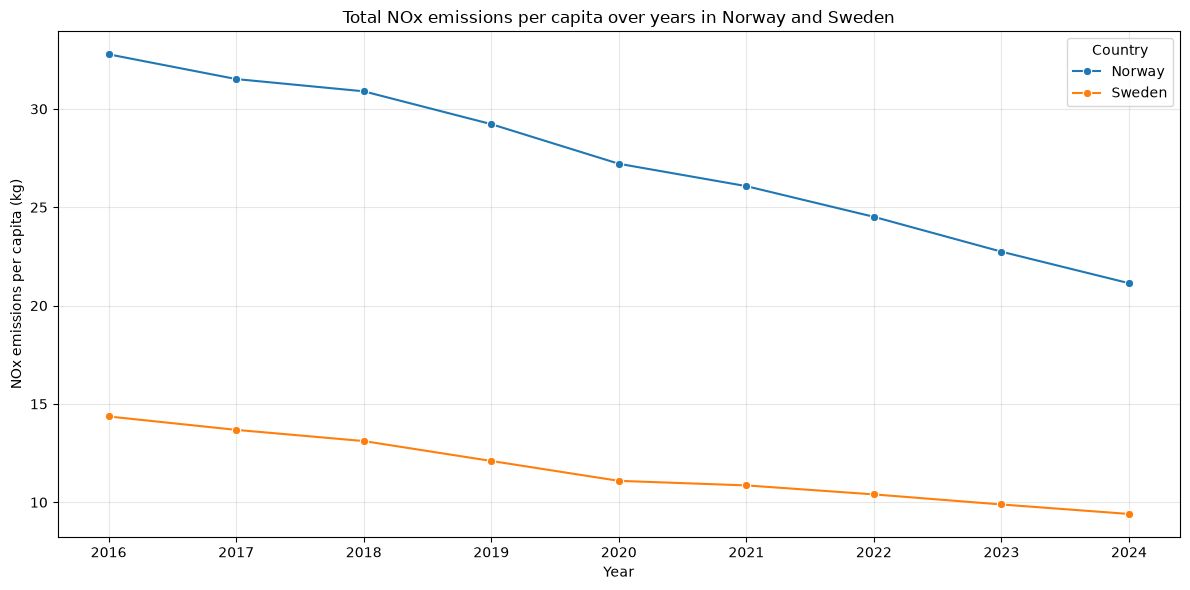

In [582]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_NOx_final_N_S,
    x="Year",
    y="Total NOx emissions per capita (kg)",
    hue="Country",
    marker="o"
)

plt.title("Total NOx emissions per capita over years in Norway and Sweden")
plt.xlabel("Year")
plt.ylabel("NOx emissions per capita (kg)")
plt.grid(True, alpha=0.3)
plt.legend(title="Country")
plt.tight_layout()
plt.show()

#### Road transport related NOx emissions per capita in EU countries

In [597]:
# 1. Create one box plot per year
fig = px.box(
    df_NOx_final,
    x="Year",
    y="Road transport emissions per capita (kg)",
    labels={
        "Year": "Year",
        "Road transport emissions per capita (kg)": "Road transport emissions per capita (kg)"
    },
    title="Road transport related NOx emissions per capita across EU Countries by Year",
    points=False
)

# Style box plots, display the mean and disable native box-plot hover labels
fig.update_traces(
    selector=dict(type="box"),
    showlegend=False,
    fillcolor="rgba(100, 100, 100, 0.20)",
    line_color="rgba(180, 180, 180, 0.85)",
    boxmean=True,
    hoveron="points",
    hoverinfo="skip"
)

# 2. Add one coloured and interactive point per country and year
for country in countries:
    country_data = df_NOx_final[
        df_NOx_final["Country"] == country
    ]

    fig.add_trace(
        go.Scatter(
            x=country_data["Year"],
            y=country_data["Road transport emissions per capita (kg)"],
            mode="markers",
            name=country,
            marker=dict(
                color=country_colors[country],
                size=8,
                opacity=0.8
            ),
            text=country_data["Country"],
            hovertemplate=(
                "<b>%{text}</b><br>"
                "Year: %{x}<br>"
                "Road transport emissions per capita (kg): %{y:.1f}"
                "<extra></extra>"
            ),
            showlegend=False
        )
    )

# 3. Calculate descriptive statistics for each year
yearly_stats = (
    df_NOx_final
    .groupby("Year")["Road transport emissions per capita (kg)"]
    .agg(
        Minimum="min",
        Q1=lambda x: x.quantile(0.25),
        Median="median",
        Mean="mean",
        Q3=lambda x: x.quantile(0.75),
        Maximum="max"
    )
    .reset_index()
)

# Place the invisible statistics trigger above each year's maximum value
y_range = (
    df_NOx_final["Road transport emissions per capita (kg)"].max()
    - df_NOx_final["Road transport emissions per capita (kg)"].min()
)

yearly_stats["hover_y"] = (
    yearly_stats["Maximum"] + 0.04 * y_range
)

# 4. Add one invisible but hoverable marker per year.
# Hover near the top of a year to see its statistical summary.
fig.add_trace(
    go.Scatter(
        x=yearly_stats["Year"],
        y=yearly_stats["hover_y"],
        mode="markers",
        marker=dict(
            size=28,
            color="rgba(0,0,0,0)"
        ),
        customdata=yearly_stats[
            ["Minimum", "Q1", "Median", "Mean", "Q3", "Maximum"]
        ].to_numpy(),
        hovertemplate=(
            "<b>Year: %{x}</b><br><br>"
            "Maximum: %{customdata[5]:.1f}<br>"
            "Q3: %{customdata[4]:.1f}<br>"
            "Mean: %{customdata[3]:.1f}<br>"
            "Median: %{customdata[2]:.1f}<br>"
            "Q1: %{customdata[1]:.1f}<br>"
            "Minimum: %{customdata[0]:.1f}"
            "<extra></extra>"
        ),
        showlegend=False
    )
)

# Improve the chart's layout and interaction
fig.update_layout(
    xaxis=dict(
        title="Year",
        type="category"
    ),
    yaxis=dict(
        title="Road transport related emissions per capita (in kg)",
        separatethousands=True
    ),
    hovermode="closest",
    template="plotly_white"
)

fig.show()

#### Road transport related NOx emissions per capita in Norway and Sweden

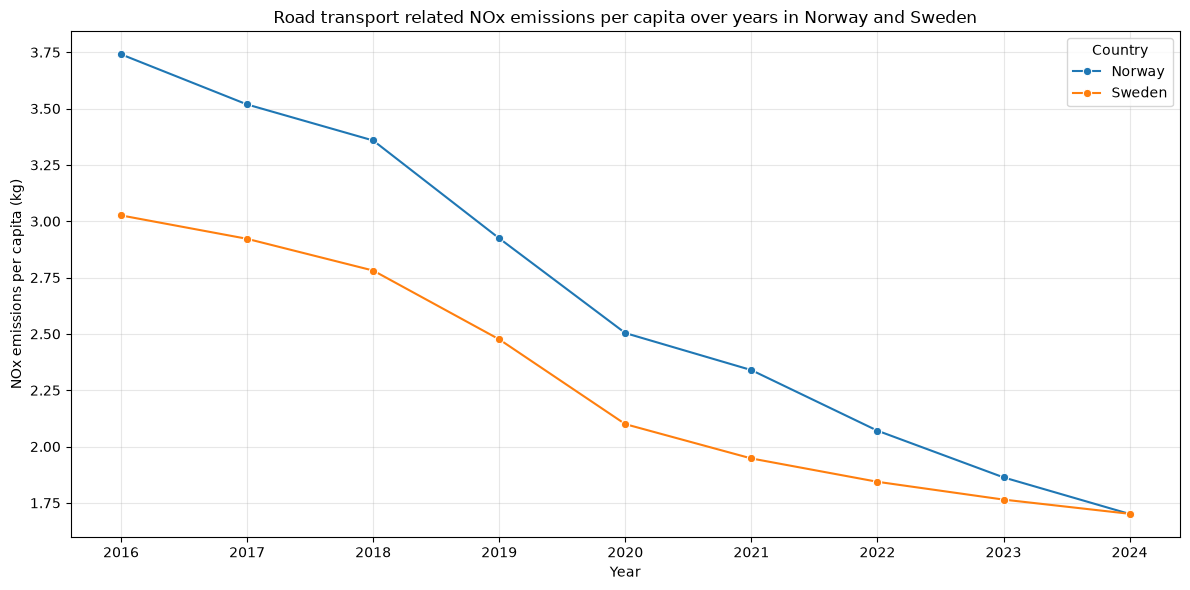

In [584]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_NOx_final_N_S,
    x="Year",
    y="Road transport emissions per capita (kg)",
    hue="Country",
    marker="o"
)

plt.title("Road transport related NOx emissions per capita over years in Norway and Sweden")
plt.xlabel("Year")
plt.ylabel("NOx emissions per capita (kg)")
plt.grid(True, alpha=0.3)
plt.legend(title="Country")
plt.tight_layout()
plt.show()

### Bivariate Analysis

We have our two final univariate dataframes : the X variable is the EV share and the Y variable is the road transport related NOx emissions.

In [590]:
df_cars_final.head()

,Country,Year,EV_cars,Total_cars,EV_share_pct
0,Austria,2016,9073.0,4821557.0,0.188176
1,Austria,2017,14618.0,4898578.0,0.298413
2,Austria,2018,20831.0,4978852.0,0.418390
3,Austria,2019,29523.0,5039548.0,0.585826
4,Austria,2020,44507.0,5091827.0,0.874087


In [591]:
df_NOx_final.head()

,Country,Year,Population,Road transport emissions (kt),Road transport emissions per capita (kg),Total NOx emissions (kt),Total NOx emissions per capita (kg),Road_transport_share_pct
0,Austria,2016,8736668.0,60.8992,6.970529,188.932,21.625178,32.233396
1,Austria,2017,8797566.0,57.7763,6.567305,178.469,20.286179,32.373297
2,Austria,2018,8840521.0,53.5562,6.058037,165.365,18.705346,32.386660
3,Austria,2019,8879920.0,48.5261,5.464700,155.719,17.536081,31.162607
4,Austria,2020,8916864.0,36.0862,4.046961,133.270,14.945837,27.077512


### Merging the univariate dataframes

In [592]:
df_bivariate_Cars_NOx = df_cars_final.merge(
    df_NOx_final,
    on=['Country', 'Year'],
    how='inner',
    validate='one_to_one'
)

df_bivariate_Cars_NOx

,Country,Year,EV_cars,Total_cars,EV_share_pct,Population,Road transport emissions (kt),Road transport emissions per capita (kg),Total NOx emissions (kt),Total NOx emissions per capita (kg),Road_transport_share_pct
0,Austria,2016,9073.0,4821557.0,0.188176,8736668.0,60.8992,6.970529,188.932,21.625178,32.233396
1,Austria,2017,14618.0,4898578.0,0.298413,8797566.0,57.7763,6.567305,178.469,20.286179,32.373297
2,Austria,2018,20831.0,4978852.0,0.418390,8840521.0,53.5562,6.058037,165.365,18.705346,32.386660
3,Austria,2019,29523.0,5039548.0,0.585826,8879920.0,48.5261,5.464700,155.719,17.536081,31.162607
4,Austria,2020,44507.0,5091827.0,0.874087,8916864.0,36.0862,4.046961,133.270,14.945837,27.077512
...,...,...,...,...,...,...,...,...,...,...,...
238,Sweden,2020,55790.0,4943293.0,1.128600,10353442.0,21.7379,2.099582,114.813,11.089356,18.933309
239,Sweden,2021,110177.0,4985979.0,2.209737,10415811.0,20.2826,1.947290,113.085,10.857052,17.935712
240,Sweden,2022,197709.0,4979761.0,3.970251,10486941.0,19.3348,1.843703,109.063,10.399887,17.728102
241,Sweden,2023,291673.0,4976366.0,5.861165,10536632.0,18.5944,1.764738,104.184,9.887790,17.847654


In [593]:
# Check the structure and completeness of the merged country-year panel

print("Dataframe shape:", df_bivariate_Cars_NOx.shape)

print("\nNumber of countries:", df_bivariate_Cars_NOx["Country"].nunique())

print("\nYears covered:")
print(
    df_bivariate_Cars_NOx["Year"]
    .agg(["min", "max", "nunique"])
)

print("\nMissing values:")
print(
    df_bivariate_Cars_NOx.isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nNumber of observations per country:")
print(
    df_bivariate_Cars_NOx
    .groupby("Country")
    .size()
    .value_counts()
    .sort_index()
)

Dataframe shape: (243, 11)

Number of countries: 27

Years covered:
min        2016
max        2024
nunique       9
Name: Year, dtype: int64

Missing values:
Country                                     0
Year                                        0
EV_cars                                     0
Total_cars                                  0
EV_share_pct                                0
Population                                  0
Road transport emissions (kt)               0
Road transport emissions per capita (kg)    0
Total NOx emissions (kt)                    0
Total NOx emissions per capita (kg)         0
Road_transport_share_pct                    0
dtype: int64

Number of observations per country:
9    27
Name: count, dtype: int64


Final analytical sample : 

The final dataset is a balanced panel of 243 country-year observations covering 27 European countries over the 2016–2024 period. Each country is observed for all nine years, and the final dataset contains no missing values in the variables used for the analysis. This enables consistent comparisons between countries and over time.

In [ ]:
# Bivariate analysis:
# Does an increase in the share of fully electric vehicles coincide with
# lower road-transport NOx emissions within countries over time?

df_bivariate_Cars_NOx_main = df_bivariate_Cars_NOx[
    [
        'Country',
        'Year',
        'EV_share_pct',
        'Road transport emissions per capita (kg)'
    ]
].copy()

df_bivariate_Cars_NOx_main.head()

,Country,Year,EV_share_pct,Road transport emissions per capita (kg)
0,Austria,2016,0.188176,6.970529
1,Austria,2017,0.298413,6.567305
2,Austria,2018,0.418390,6.058037
3,Austria,2019,0.585826,5.464700
4,Austria,2020,0.874087,4.046961


### Country-level correlations

In [613]:
# Pearson correlation between EV share and road-transport NOx per capita,
# calculated separately within each country over 2016–2024

country_correlations = (
    df_bivariate_Cars_NOx_main
    .groupby('Country')
    .apply(
        lambda country_data: country_data['EV_share_pct'].corr(
            country_data['Road transport emissions per capita (kg)'],
            method='pearson'
        )
    )
    .reset_index(name='pearson_correlation')
    .sort_values('pearson_correlation')
    .reset_index(drop=True)
)

country_correlations.round(3).head()

,Country,pearson_correlation
0,Norway,-0.969
1,Lithuania,-0.951
2,Estonia,-0.930
3,Netherlands,-0.897
4,Germany,-0.857


For each country, we calculate a Pearson correlation coefficient between EV share and road-transport NOx emissions per capita over 2016–2024. A coefficient close to \(-1\) indicates that higher EV shares strongly coincide with lower NOx emissions; a coefficient close to \(0\) indicates no clear linear association; and a coefficient close to \(+1\) indicates that both variables increase together.

Most countries show a negative relationship. For example, Norway (\(r = -0.969\)), Lithuania (\(r = -0.951\)), the Netherlands (\(r = -0.897\)), Germany (\(r = -0.857\)), Sweden (\(r = -0.846\)), Austria (\(r = -0.836\)) and France (\(r = -0.831\)) have strong negative correlations. In contrast, Cyprus shows almost no association (\(r = -0.064\)), while Croatia (\(r = 0.754\)) and Romania (\(r = 0.884\)) show positive correlations.

These results are descriptive only: they show correlation, not a causal effect of EV adoption on NOx emissions.

### Norway and Sweden: considered country comparison

We next focus on Norway and Sweden. Both countries are Nordic and "comparable" countries but Norway has implemented particularly strong and long-lasting incentives for electric vehicles, including tax exemptions and reduced road-toll, parking and ferry costs. This makes Norway a relevant case to compare with Sweden when exploring the association between EV adoption and road-transport NOx emissions.

In [608]:
# Scatter plots for Norway and Sweden

df_bivariate_Cars_NOx_main_N_S = df_bivariate_Cars_NOx_main[
    df_bivariate_Cars_NOx_main['Country'].isin(considered_countries)
].copy()

fig = px.scatter(
    df_bivariate_Cars_NOx_main_N_S,
    x='EV_share_pct',
    y='Road transport emissions per capita (kg)',
    facet_col='Country',
    color='Country',
    hover_data=['Year'],
    trendline='ols',
    labels={
        'EV_share_pct': 'EV share of the car fleet (%)',
        'Road transport emissions per capita (kg)': 'Road-transport NOx emissions per capita (kg)',
        'Country': ''
    },
    title='EV share and road-transport NOx emissions per capita: Norway and Sweden'
)

# Independent scales: Norway and Sweden have very different EV-share ranges
fig.update_xaxes(matches=None, showticklabels=True)
fig.update_yaxes(matches=None, showticklabels=True)

# Replace "Country=Norway" and "Country=Sweden" with country names only
fig.for_each_annotation(lambda a: a.update(text=a.text.split('=')[-1]))

# Small notebook-friendly layout, without redundant legend
fig.update_layout(
    showlegend=False,
    width=900,
    height=520,
    margin=dict(l=70, r=30, t=80, b=70),
    grid=dict(columns=2, pattern='independent', xgap=0.12)
)

fig.show()

In [612]:
country_correlation_results = country_correlations.copy()

country_correlation_results['R_squared'] = (
    country_correlation_results['pearson_correlation'] ** 2
)

country_correlation_results = country_correlation_results.rename(
    columns={
        'pearson_correlation': 'Pearson_r'
    }
)

country_correlation_results.round(3).head()

,Country,Pearson_r,R_squared
0,Norway,-0.969,0.939
1,Lithuania,-0.951,0.905
2,Estonia,-0.930,0.865
3,Netherlands,-0.897,0.805
4,Germany,-0.857,0.734
